# Ejercicio 2

Minimizar $z = \sum_{t=1}^{6} c_t x_t + \sum_{t=1}^{6} h_t I_t$

Sujeto a
$$
I_t = I_{t-1} + x_t - d_t, \quad t=1,\dots,6\\
I_0 = 0\\
0 \leq x_t \leq 225, \quad t=1,\dots,6\\
I_t \geq 0, \quad t=1,\dots,6
$$

## Solución

In [1]:
using JuMP
using HiGHS

In [2]:
model = Model()

T = 6

demanda = [180, 250, 190, 140, 220, 250]
costo_produccion = [50, 45, 55, 52, 48, 50]
costo_inventario = [8, 10, 10, 10, 8, 8]
capacidad = 225

@variable(model, 0 <= x[1:T] <= capacidad)
@variable(model, I[0:T] >= 0)

@constraint(model, I[0] == 0)
@constraint(model, [t in 1:T], I[t] == I[t-1] + x[t] - demanda[t])

@objective(model, Min, sum(costo_produccion[t] * x[t] + costo_inventario[t] * I[t] for t in 1:T))

50 x[1] + 8 I[1] + 45 x[2] + 10 I[2] + 55 x[3] + 10 I[3] + 52 x[4] + 10 I[4] + 48 x[5] + 8 I[5] + 50 x[6] + 8 I[6]

In [3]:
set_optimizer(model, HiGHS.Optimizer)

model

A JuMP Model
├ solver: HiGHS
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 13
├ num_constraints: 26
│ ├ AffExpr in MOI.EqualTo{Float64}: 7
│ ├ VariableRef in MOI.GreaterThan{Float64}: 13
│ └ VariableRef in MOI.LessThan{Float64}: 6
└ Names registered in the model
  └ :I, :x

In [4]:
optimize!(model)

print("\n")
print("x = ", value.(x), "\n")
print("I = ", value.(I), "\n")
print("costo total = ", objective_value(model))

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: libblastrampoline 
LP has 7 rows; 13 cols; 19 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [8e+00, 6e+01]
  Bound   [2e+02, 2e+02]
  RHS     [1e+02, 2e+02]
Presolving model
5 rows, 11 cols, 15 nonzeros 0s
3 rows, 8 cols, 10 nonzeros 0s
2 rows, 7 cols, 8 nonzeros 0s
Dependent equations search running on 2 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2 rows, 7 cols, 8 nonzeros 0s
Presolve reductions: rows 2(-5); columns 7(-6); nonzeros 8(-11) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     2.1175000000e+04 Pr: 2(800) 0.0s
          3     6.1795000000e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution aft

[205.0, 225.0, 190.0, 160.0, 225.0, 225.0]
I = 

1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, 0:6
And data, a 7-element Vector{Float64}:
 -0.0
 25.0
  0.0
  0.0
 20.0
 25.0
  0.0
costo total = 

61795.0

## Datos y visualizaciones

In [5]:
x_opt = [value(x[t]) for t in 1:T]
I_opt = [value(I[t]) for t in 1:T]

println("I0 = 0")
for t in 1:T
    println("x$t = $(x_opt[t])   D$t = $(demanda[t])   I$t = $(I_opt[t])")
end

I0 = 0
x1 = 205.0   D1 = 180   I1 = 25.0


x2 = 225.0   D2 = 250   I2 = 0.0
x3 = 190.0   D3 = 190   I3 = 0.0
x4 = 160.0   D4 = 140   I4 = 20.0
x5 = 225.0   D5 = 220   I5 = 25.0
x6 = 225.0   D6 = 250   I6 = 0.0


In [6]:
x_no_opt = Float64.(demanda)
I_no_opt = zeros(T)

costo_prod_opt = costo_produccion .* x_opt
costo_inv_opt = costo_inventario .* I_opt
costo_total_opt = costo_prod_opt .+ costo_inv_opt

costo_prod_no_opt = costo_produccion .* x_no_opt
costo_inv_no_opt = costo_inventario .* I_no_opt
costo_total_no_opt = costo_prod_no_opt .+ costo_inv_no_opt

ahorro = costo_total_no_opt .- costo_total_opt

6-element Vector{Float64}:
 -1450.0
  1125.0
     0.0
 -1240.0
  -440.0
  1250.0

In [7]:
println(rpad("Mes", 6), rpad("Costo Prod.", 14), rpad("Costo Inv.", 14), rpad("Costo Total", 14), rpad("Costo Total (no opt)", 22), "Ahorro")
for t in 1:T
    println(rpad(t, 6), rpad(costo_prod_opt[t], 14), rpad(costo_inv_opt[t], 14), rpad(costo_total_opt[t], 14), rpad(costo_total_no_opt[t], 22), ahorro[t])
end
println(rpad("Total", 6), rpad(sum(costo_prod_opt), 14), rpad(sum(costo_inv_opt), 14), rpad(sum(costo_total_opt), 14), rpad(sum(costo_total_no_opt), 22), sum(ahorro))

Mes   Costo Prod.   Costo Inv.    Costo Total   Costo Total (no opt)  Ahorro
1     10250.0       200.0         10450.0       9000.0                -1450.0
2     10125.0       0.0           10125.0       11250.0               1125.0
3     10450.0       0.0           10450.0       10450.0               0.0
4     8320.0        200.0         8520.0        7280.0                -1240.0
5     10800.0       200.0         11000.0       10560.0               -440.0
6     11250.0       0.0           11250.0       12500.0               1250.0
Total 61195.0       600.0         61795.0       61040.0               -755.0


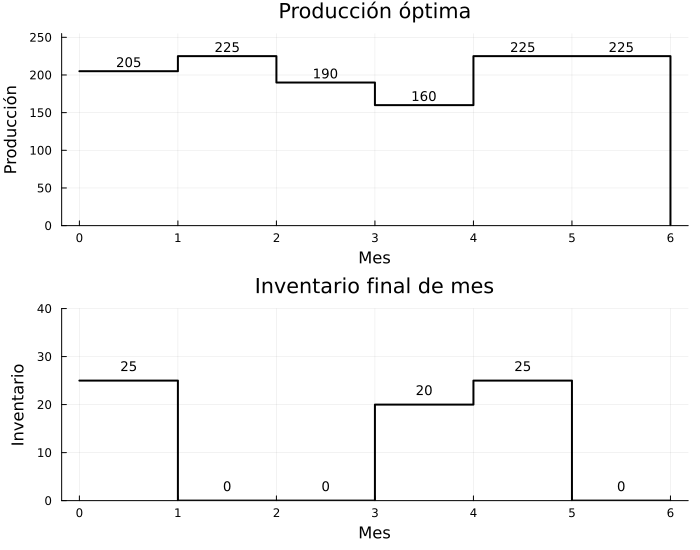

In [8]:
using Plots
gr()

edges = 0:T
xs = repeat(edges, inner=2)[2:end-1]

ys_x = vcat(repeat(x_opt, inner=2), 0)
xs_x = vcat(xs, T)

p1 = plot(xs_x, ys_x, linewidth=2, color=:black, legend=false,
    xticks=(0:T, string.(0:T)), xlabel="Mes", ylabel="Producción",
    ylim=(0, capacidad + 30), title="Producción óptima")
for t in 1:T
    annotate!(p1, t - 0.5, x_opt[t] + 12, text(string(Int(x_opt[t])), 9))
end

ys_I = vcat(repeat(I_opt, inner=2), 0)
xs_I = vcat(xs, T)

p2 = plot(xs_I, ys_I, linewidth=2, color=:black, legend=false,
    xticks=(0:T, string.(0:T)), xlabel="Mes", ylabel="Inventario",
    ylim=(0, maximum(I_opt) + 15), title="Inventario final de mes")
for t in 1:T
    annotate!(p2, t - 0.5, I_opt[t] + 3, text(string(Int(I_opt[t])), 9))
end

plot(p1, p2, layout=(2, 1), size=(700, 550))